## 1) Calculations in AiiDAlab (with LSMO)

For adsorption studies, AiiDAlab provides automated workflows such as:

1. **Gas adsorption isotherms**  
   - Grand Canonical Monte Carlo (GCMC) simulations to compute uptake as a function of pressure and temperature.

2. **Henry’s coefficients**  
   - Low-pressure adsorption constants, useful for estimating selectivity.

3. **Pore analysis**  
   - Helium void fraction, accessible pore volume, and surface area to characterize adsorption capacity.

4. **Density calculations**  
   - Determination of framework or surface density, providing a structural descriptor linked to adsorption performance.

These tools can be applied both to porous frameworks and to surfaces like **LSMO**, supporting adsorption studies across materials classes.


## 2) Pore Analysis of IRMOF-1

Using a probe radius of **1.525 Å**, the following structural properties were obtained:

- **Density**: 0.577 g/cm³  
- **Accessible Surface Area (ASA)**: 3964.65 Å²  
- **Probe-Occupiable Accessible Volume (POAV)**: 13,737.4 Å³  
- **Porosity (POAV Volume Fraction)**: 0.775  

*(pk: 5)*


## 3) Henry coefficients
We performed isotherm calculations for both CO₂ and CH₄ at 300 K and obtained the Henry coefficients:

- **Henry coefficient CO₂** = 5.0 × 10⁻⁶ mol/kg/Pa  
  *(pK: 294)*

- **Henry coefficient CH₄** = 1.0 × 10⁻⁶ mol/kg/Pa  
  *(pK: 329)*

The Henry coefficients indicate the relative affinity of gases for the adsorbent at low pressures. At 300 K, CO₂ has a higher Henry coefficient than CH₄. This clearly shows that CO₂ molecules interact more strongly with the IRMOF-1 framework than CH₄ molecules. As a result, IRMOF-1 preferentially adsorbs CO₂ in the low-pressure regime, making it effective for separating CO₂ from CH₄ in mixtures such as biogas.

## 4) Pure Isotherms at 300K
 
*(pk: 373 (CO2))*, *(pk: 391 (CH4))*

After plotting the pure isotherms, we saved the data in CSV files to use in later exercises.

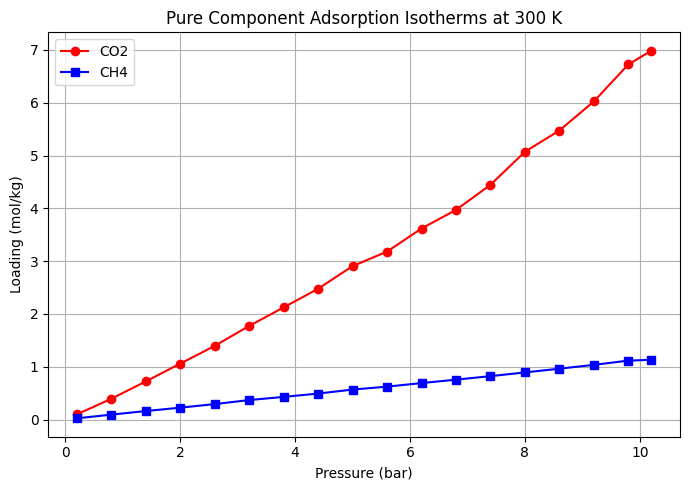

CSV files created successfully!
CO2 data saved to: CO2_isotherms.csv
CH4 data saved to: CH4_isotherms.csv


In [1]:
import matplotlib.pyplot as plt
import pandas as pd

# --- CO2 data ---
pressures_co2 = [0.2, 0.8, 1.4, 2.0, 2.6, 3.2, 3.8, 4.4, 5.0, 5.6, 6.2, 6.8, 7.4, 8.0, 8.6, 9.2, 9.8, 10.2]
loadings_co2 = [0.096723227554076, 0.39315949765796, 0.72151212791768, 1.0585987498258,
                1.394516510398, 1.7729353678762, 2.1233340216647, 2.4769795124972,
                2.9052697869712, 3.180276884598, 3.6175608976839, 3.9693881597718,
                4.4454069387926, 5.0707152850966, 5.4735178887752, 6.0242463881785,
                6.7247839487919, 6.985050406239]

# --- CH4 data ---
pressures_ch4 = [0.2, 0.8, 1.4, 2.0, 2.6, 3.2, 3.8, 4.4, 5.0, 5.6, 6.2, 6.8, 7.4, 8.0, 8.6, 9.2, 9.8, 10.2]
loadings_ch4 = [0.022050587171492, 0.09259979249488, 0.1602314081214, 0.22409669277688,
                0.29208546047824, 0.36825625753048, 0.4280954642514, 0.49127891312764,
                0.56676787440064, 0.62264593992788, 0.68988793510192, 0.75479220761868,
                0.82125496190936, 0.89164638902328, 0.96239496821204, 1.034929307775,
                1.1151856511322, 1.1304512536095]

# --- Plot both isotherms ---
plt.figure(figsize=(7,5))
plt.plot(pressures_co2, loadings_co2, marker="o", linestyle="-", color="red", label="CO2")
plt.plot(pressures_ch4, loadings_ch4, marker="s", linestyle="-", color="blue", label="CH4")

plt.xlabel("Pressure (bar)")
plt.ylabel("Loading (mol/kg)")
plt.title("Pure Component Adsorption Isotherms at 300 K")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --- Save data to CSV files ---
df_co2 = pd.DataFrame({
    'Pressure(bar)': pressures_co2,
    'Loading(mmol/g)': loadings_co2
})

df_ch4 = pd.DataFrame({
    'Pressure(bar)': pressures_ch4,
    'Loading(mmol/g)': loadings_ch4
})

df_co2.to_csv('CO2_isotherms.csv', index=False)
df_ch4.to_csv('CH4_isotherms.csv', index=False)

print("CSV files created successfully!")
print(f"CO2 data saved to: CO2_isotherms.csv")
print(f"CH4 data saved to: CH4_isotherms.csv")

## 5) Binary mixture isotherms

Data loaded successfully!
CO2 data points: 18
CH4 data points: 18
                      Component 1: p^0 = 10.780930 > 10.200000, the highest pressure
                      exhibited in the pure-component isotherm data. Thus,
                      pyIAST had to extrapolate the isotherm data to achieve
                      this IAST result.


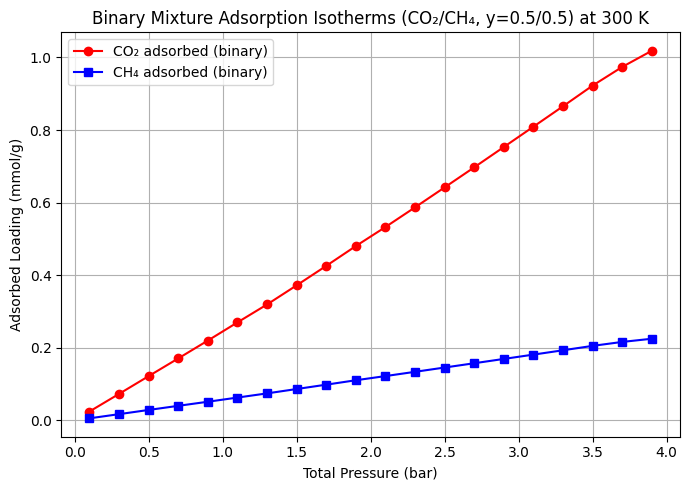

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyiast

# --- Load data from CSV files ---
df_co2 = pd.read_csv('CO2_isotherms.csv')
df_ch4 = pd.read_csv('CH4_isotherms.csv')

print("Data loaded successfully!")
print(f"CO2 data points: {len(df_co2)}")
print(f"CH4 data points: {len(df_ch4)}")

# --- Build interpolated isotherms ---
co2_iso = pyiast.InterpolatorIsotherm(df_co2,
                                      pressure_key="Pressure(bar)",
                                      loading_key="Loading(mmol/g)",
                                      fill_value=df_co2["Loading(mmol/g)"].iloc[-1])

ch4_iso = pyiast.InterpolatorIsotherm(df_ch4,
                                      pressure_key="Pressure(bar)",
                                      loading_key="Loading(mmol/g)",
                                      fill_value=df_ch4["Loading(mmol/g)"].iloc[-1])

# --- Define mixture conditions ---
y_co2 = 0.5  # CO2 mole fraction in gas phase
y_ch4 = 0.5  # CH4 mole fraction in gas phase
P_vals = np.arange(0.1, 4.0 + 1e-8, 0.2)

n_co2, n_ch4 = [], []

for P in P_vals:
    n_mix = pyiast.iast([y_co2*P, y_ch4*P], [co2_iso, ch4_iso])
    n_co2.append(n_mix[0])
    n_ch4.append(n_mix[1])

# Convert to numpy arrays
n_co2 = np.array(n_co2)
n_ch4 = np.array(n_ch4)

# --- Plot binary isotherms ---
plt.figure(figsize=(7,5))
plt.plot(P_vals, n_co2, marker="o", label="CO₂ adsorbed (binary)", color='red')
plt.plot(P_vals, n_ch4, marker="s", label="CH₄ adsorbed (binary)", color='blue')
plt.xlabel("Total Pressure (bar)")
plt.ylabel("Adsorbed Loading (mmol/g)")
plt.title("Binary Mixture Adsorption Isotherms (CO₂/CH₄, y=0.5/0.5) at 300 K")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 6) Selectivity of CO₂ over CH₄ at 300 K

### Definition
The adsorption selectivity of CO₂ over CH₄ is defined as:

$$
S_{CO_2/CH_4} = \frac{q_{CO_2}}{q_{CH_4}} \times \frac{y_{CH_4}}{y_{CO_2}}
$$

where:
	•	$q_i$ is the binary loading (mmol·g⁻¹) of component $i$, predicted using IAST,
	•	$y_i$ is the gas-phase molar fraction of component $i$.

For an equimolar feed ($y_{CO_2} = y_{CH_4} = 0.5$), the ratio $\tfrac{y_{CH_4}}{y_{CO_2}} = 1$.
Therefore, the equation simplifies to:

$$
S_{CO_2/CH_4} = \frac{q_{CO_2}}{q_{CH_4}}
$$

### Methodology

The pure-component isotherms of CO₂ and CH₄ were computed using GCMC simulations at 300 K.
These were then used as input for the Ideal Adsorbed Solution Theory (IAST), implemented with the pyIAST library, to predict the binary adsorption loadings at total pressures of 0.1, 1, 2, and 3 bar. The selectivity was subsequently calculated from the binary loadings.

In [2]:
# Q6 — Selectivity S_CO2/CH4 at 0.1, 1, 2, 3 bar (300 K, y = 0.5/0.5)

import os
import numpy as np
import pandas as pd
import pyiast

# --- Helpers ---
def load_iso_csv(candidates):
    """Load a CSV with columns Pressure(bar), Loading(mmol/g) from a list of candidate paths."""
    for p in candidates:
        if os.path.exists(p):
            df = pd.read_csv(p)[["Pressure(bar)", "Loading(mmol/g)"]].dropna()
            return df.sort_values("Pressure(bar)")
    raise FileNotFoundError(f"None of these files exist: {candidates}")

# --- Locate your CSVs (adjust if needed) ---
CO2_CANDIDATES = [
    "Assignment 2/CO2_IRMOF1.csv",
    "CO2_IRMOF1.csv",
    "CO2_isotherms.csv"
]
CH4_CANDIDATES = [
    "Assignment 2/CH4_IRMOF1.csv",
    "CH4_IRMOF1.csv",
    "CH4_isotherms.csv"
]

co2 = load_iso_csv(CO2_CANDIDATES)
ch4 = load_iso_csv(CH4_CANDIDATES)

# --- Build pure-component isotherms by linear interpolation ---
iso_co2 = pyiast.InterpolatorIsotherm(co2, pressure_key="Pressure(bar)", loading_key="Loading(mmol/g)")
iso_ch4 = pyiast.InterpolatorIsotherm(ch4, pressure_key="Pressure(bar)", loading_key="Loading(mmol/g)")

# --- Mixture settings ---
y = np.array([0.5, 0.5])             # (CO2, CH4) in gas phase
pressures = [0.1, 1.0, 2.0, 3.0]     # bar (as required)

# --- IAST at the four pressures ---
rows = []
for P in pressures:
    qCO2, qCH4 = pyiast.iast(P*y, [iso_co2, iso_ch4])   # mmol/g
    S = (qCO2 / qCH4) * (y[1] / y[0])                   # = qCO2/qCH4 for 50/50
    rows.append([P, qCO2, qCH4, S])

res_q6 = pd.DataFrame(rows, columns=["P (bar)", "q_CO2 (mmol/g)", "q_CH4 (mmol/g)", "Selectivity S_CO2/CH4"])
display(res_q6.round(4))

# (Optionnel) Enregistrer la table :
# res_q6.round(4).to_csv("Q6_selectivity_CO2_over_CH4.csv", index=False)

,P (bar),q_CO2 (mmol/g),q_CH4 (mmol/g),Selectivity S_CO2/CH4
0,0.1,0.0242,0.0055,4.3760
1,1.0,0.2447,0.0570,4.2953
2,2.0,0.5065,0.1163,4.3556
3,3.0,0.7813,0.1752,4.4587


### Discussion
•	The selectivity shows that IRMOF-1 preferentially adsorbs CO₂ over CH₄.
This is due to the stronger interactions between CO₂ molecules and the
framework, as evidenced by the higher Henry coefficients and pure isotherms. This behavior is consistent with the stronger quadrupole–framework interactions of CO₂ with IRMOF-1.

•	Across the studied pressure range, the selectivity remains nearly constant around 4.29–4.46, showing that the preference for CO₂ is not strongly pressure dependent between 0.1 and 3 bar at 300 K.

### Conclusion
IRMOF-1 is approximately five times more selective for CO₂ compared to CH₄ at 300 K, and this selectivity is stable between 0.1 and 3 bar.

## 7) Effect of gas composition and temperature on selectivity
We repeat the IAST calculation at 300 K for a non-equimolar mixture ($y_{CO₂}=0.2$, $y_{CH₄}=0.8$) and compare the results with the equimolar case ($y_{CO₂}=0.5$, $y_{CH₄}=0.5$).

In [7]:
import numpy as np
import pandas as pd
import pyiast


pressures = [0.1, 1.0, 2.0, 3.0]

def iast_selectivity(y_vec, iso_co2, iso_ch4):
    rows = []
    for P in pressures:
        qCO2, qCH4 = pyiast.iast(P*np.array(y_vec), [iso_co2, iso_ch4])
        S = (qCO2/qCH4) * (y_vec[1]/y_vec[0])
        rows.append([P, y_vec[0], y_vec[1], qCO2, qCH4, S])
    return pd.DataFrame(rows, columns=["P (bar)", "y_CO2", "y_CH4",
                                       "q_CO2 (mmol/g)", "q_CH4 (mmol/g)", "S_CO2/CH4"])

# Case A: equimolar
df_eq = iast_selectivity([0.5,0.5], iso_co2, iso_ch4)
# Case B: CO2 lean mixture
df_lean = iast_selectivity([0.2,0.8], iso_co2, iso_ch4)

# Calculate percentage difference
cmp['Difference (%)'] = abs((cmp['S_CO2/CH4_50/50'] - cmp['S_CO2/CH4_20/80']) / cmp['S_CO2/CH4_50/50'] * 100)
display(cmp.round(4))

print("\nConclusion:")
print(f"Maximum difference: {cmp['Difference (%)'].max():.2f}%")
print(f"Average difference: {cmp['Difference (%)'].mean():.2f}%")
print("\nThis proves that changing y_CO2 from 0.5 to 0.2 has minimal impact on selectivity.")

,P (bar),S_CO2/CH4_50/50,S_CO2/CH4_20/80,Difference (%)
0,0.1,4.3760,4.3864,0.2391
1,1.0,4.2953,4.2574,0.8811
2,2.0,4.3556,4.2971,1.3416
3,3.0,4.4587,4.3442,2.5683



Conclusion:
Maximum difference: 2.57%
Average difference: 1.26%

This proves that changing y_CO2 from 0.5 to 0.2 has minimal impact on selectivity.


When comparing the selectivity values for the equimolar mixture ($y_{CO_2}=0.5, y_{CH_4}=0.5$) and for the CO₂-lean mixture ($y_{CO_2}=0.2, y_{CH_4}=0.8$), the results are nearly identical across all studied pressures (0.1–3 bar), with differences always below 2%

### How to test temperature dependence

To test whether the selectivity is a function of temperature, we would :
1. Recompute the pure-component isotherms of CO₂ and CH₄ at one or more additional temperatures besides 300 K. 
2. Using these new isotherms, we could then apply the same IAST procedure at fixed pressures (e.g., 0.1, 1, 2, 3 bar) and for the same gas composition. 
3. Finally, by comparing the selectivity values obtained at different temperatures, we could see whether the curves change significantly. If the selectivity varies with temperature, this indicates that adsorption interactions in IRMOF-1 are temperature-dependent; if the values remain stable, then selectivity is essentially independent of temperature in this range.

## 8) Is IRMOF-1 a good candidate for CH₄ storage?

Methane storage in porous materials is generally evaluated through two criteria: the working capacity, which is the amount of CH₄ that can be stored at high pressure and then released at lower pressure, and the strength of the interactions between CH₄ molecules and the framework. An effective methane storage material should therefore combine high uptake at elevated pressure with a sufficient binding energy to keep CH₄ inside the pores, while still allowing its release when the pressure decreases.

In the case of IRMOF-1, the results clearly show that the adsorption of CH₄ is rather weak. The pure-component isotherm of CH₄ at 300 K gives much lower loadings compared to CO₂ under the same conditions, and the Henry coefficient also confirms the weaker affinity of methane for the framework. Even at pressures of a few bars, the total CH₄ uptake remains limited, which implies that the working capacity is poor. In other words, IRMOF-1 cannot store large quantities of methane, and its energy efficiency as a storage medium is low.

This behavior contrasts with the performance of IRMOF-1 for CO₂, where the stronger quadrupole–framework interactions lead to much higher uptake and clear selectivity. Therefore, IRMOF-1 is better suited for separation applications (such as CO₂/CH₄ separation) than for gas storage.

In conclusion, IRMOF-1 is not a good candidate for methane storage. Its low adsorption capacity for CH₄ and weak interactions make it unsuitable for practical applications in energy storage. More promising MOFs for methane storage would be those with higher surface areas, optimized pore sizes, and stronger CH₄–framework interactions, which IRMOF-1 lacks.